<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/19_neural_networks/19_1_Neural_Networks/19_1_1_Anatomy_of_a_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks: Part 1
## Anatomy of a Network

---

## What This Notebook Is About

In notebook 18_2_3, you saw sklearn's `MLPClassifier` solve the XOR problem that logistic regression cannot. MLPClassifier was a black box: you set `hidden_layer_sizes`, called `.fit()`, and got predictions. The weights were somewhere inside, but you could not see how the computation was organized.

In notebook 19_0_3, you wrote the training loop from scratch — the five-step cycle of zeroing gradients, making predictions, computing loss, calling `.backward()`, and updating parameters. But the model itself was just two scalars, `w` and `b`.

This notebook connects those two threads. You will build the same network that MLPClassifier used — a feedforward neural network with a hidden layer — from scratch in PyTorch, using `nn.Module`. Opening the hood reveals exactly how the layers, the weights, and the forward computation fit together.

**What you will learn:**
1. The `nn.Module` contract: `__init__` defines the layers, `forward` defines the computation
2. `nn.Linear`: the fundamental building block — a weight matrix and a bias vector
3. How logistic regression and a single neuron are identical in `nn.Module` terms
4. How adding a hidden layer lets a network solve problems a single neuron cannot
5. `nn.Sequential` as a shorthand for simple layer stacks
6. How to introspect any network: parameter shapes, counts, and names

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn

torch.manual_seed(0)

# XOR — the same four points from notebook 18_2_3
X_xor = torch.tensor([[0., 0.],
                       [0., 1.],
                       [1., 0.],
                       [1., 1.]])
y_xor = torch.tensor([[0.], [1.], [1.], [0.]])

print('XOR dataset:')
for xi, yi in zip(X_xor, y_xor):
    print(f'  x={xi.tolist()}  →  y={yi.item():.0f}')

XOR dataset:
  x=[0.0, 0.0]  →  y=0
  x=[0.0, 1.0]  →  y=1
  x=[1.0, 0.0]  →  y=1
  x=[1.0, 1.0]  →  y=0


---

## Section 1: The `nn.Module` Contract

Every PyTorch model — from logistic regression to a 100-layer network — is a Python class that inherits from `nn.Module`. The class has exactly two responsibilities:

- **`__init__`:** Define and register the layers. Any `nn.Module` or `nn.Parameter` you assign as an attribute is automatically tracked — PyTorch knows its weights are trainable and handles moving them to a device.
- **`forward(x)`:** Define the computation. Given input `x`, this method returns the model's output. You never call `forward` directly; you call the model like a function — `model(x)` — and PyTorch calls `forward` for you.

That is the entire contract. Everything else (gradient tracking, device management, saving weights) happens automatically.

In [2]:
# The smallest possible PyTorch network: one linear layer, sigmoid output
class MinimalNet(nn.Module):
    def __init__(self):
        super().__init__()             # always call super().__init__() first
        self.layer = nn.Linear(2, 1)  # define layers as attributes here

    def forward(self, x):
        return torch.sigmoid(self.layer(x))  # define computation here

net = MinimalNet()

# Calling the model runs forward(x) automatically
out = net(X_xor)
print(f'Output shape : {out.shape}')           # (4, 1) — one prediction per sample
print(f'Output values: {out.detach().squeeze().round(decimals=3)}')
print()

# nn.Linear(in_features, out_features) wraps a weight matrix and a bias vector
print('nn.Linear(2, 1) contains:')
print(f'  weight : shape {list(net.layer.weight.shape)}  (out_features × in_features)')
print(f'  bias   : shape {list(net.layer.bias.shape)}')
print(f'  forward: output = input @ weight.T + bias')

Output shape : torch.Size([4, 1])
Output values: tensor([0.3580, 0.4500, 0.3570, 0.4480])

nn.Linear(2, 1) contains:
  weight : shape [1, 2]  (out_features × in_features)
  bias   : shape [1]
  forward: output = input @ weight.T + bias


---

## Section 2: Logistic Regression Is a One-Layer Network

In notebook 18_2_3 you verified numerically that logistic regression computes σ(W·x + b): a linear combination of the inputs passed through a sigmoid. That is exactly one `nn.Linear` layer followed by `torch.sigmoid`.

Let's implement it as an `nn.Module` and verify the output is identical to the weight-formula computation — the same check you did in 18_2_3 Section 1, now with your own module.

In [3]:
class LogisticRegressionModule(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

torch.manual_seed(7)
lr_mod    = LogisticRegressionModule(n_features=2)
x_sample  = X_xor[:1]   # one row, shape (1, 2)

# Run through the module
p_module  = lr_mod(x_sample)

# Compute manually: σ(W·x + b)
W = lr_mod.linear.weight   # shape (1, 2)
b = lr_mod.linear.bias     # shape (1,)

with torch.no_grad():
    z      = x_sample @ W.T + b    # (1,2) @ (2,1) + (1,) = (1,1)
    p_hand = torch.sigmoid(z)

print('Verifying  p = σ(Wx + b):')
print(f'  module output : {p_module.item():.8f}')
print(f'  manual formula: {p_hand.item():.8f}')
print(f'  difference    : {abs(p_module.item() - p_hand.item()):.2e}')
print()
print('Identical — this is the same result confirmed in notebook 18_2_3 Section 1.')
print('One nn.Linear + sigmoid  =  one artificial neuron  =  logistic regression.')

Verifying  p = σ(Wx + b):
  module output : 0.55605322
  manual formula: 0.55605322
  difference    : 0.00e+00

Identical — this is the same result confirmed in notebook 18_2_3 Section 1.
One nn.Linear + sigmoid  =  one artificial neuron  =  logistic regression.


---

## Section 3: Adding a Hidden Layer — XORNet

Logistic regression draws a straight decision boundary. XOR is not linearly separable — no straight line can correctly classify all four points. You saw this in 18_2_3 Section 2.

The fix is a **hidden layer**: an intermediate set of neurons that transform the input into a new representation. In that new space the task becomes linearly separable, and the output neuron (which is still a logistic regression) draws a straight line there.

The hidden layer uses **ReLU** as its activation function — the same activation you saw in 18_2_3 Section 3. ReLU is `max(0, z)`: it passes positive values unchanged and clips negative values to zero. This non-linearity is what gives the network the ability to learn curved decision boundaries.

Below, we define the network, draw its architecture, then train it using the five-step loop from notebook 19_0_3.

XORNet parameter shapes:
  hidden.weight           shape: [4, 2]  (8 params)
  hidden.bias             shape: [4]  (4 params)
  output.weight           shape: [1, 4]  (4 params)
  output.bias             shape: [1]  (1 params)
  Total: 17 trainable parameters



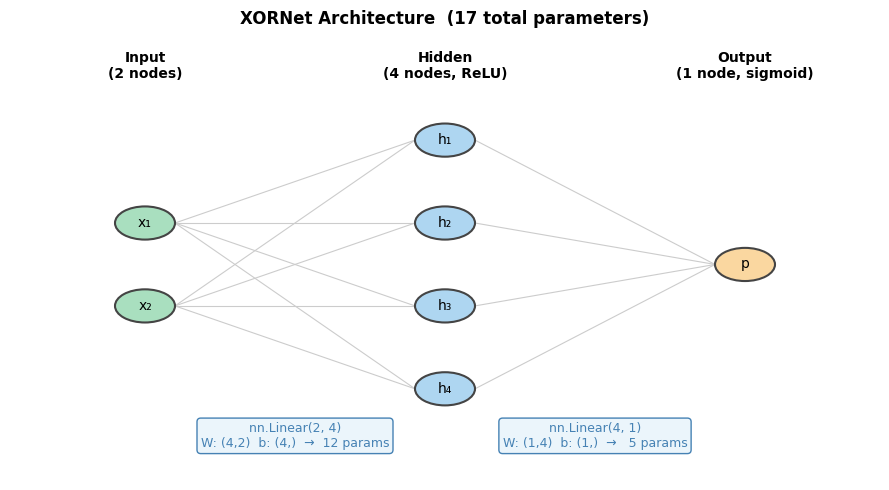

In [4]:
class XORNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)   # 2 inputs  → 4 hidden neurons
        self.output = nn.Linear(4, 1)   # 4 hidden  → 1 output

    def forward(self, x):
        h = torch.relu(self.hidden(x))       # hidden layer: linear + ReLU
        return torch.sigmoid(self.output(h)) # output layer: linear + sigmoid

# Show parameter shapes before training
print('XORNet parameter shapes:')
for name, param in XORNet().named_parameters():
    print(f'  {name:<22}  shape: {list(param.shape)}  ({param.numel()} params)')
total = sum(p.numel() for p in XORNet().parameters())
print(f'  Total: {total} trainable parameters')
print()

# Architecture diagram
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(-0.4, 5.4)
ax.set_ylim(-1.1, 4.3)
ax.axis('off')

lx = {'input': 0.5, 'hidden': 2.5, 'output': 4.5}
ly = {'input': [2.0, 1.0], 'hidden': [3.0, 2.0, 1.0, 0.0], 'output': [1.5]}
colors_ = {'input': '#A9DFBF', 'hidden': '#AED6F1', 'output': '#FAD7A0'}
labels_ = {'input': ['x₁','x₂'], 'hidden': ['h₁','h₂','h₃','h₄'], 'output': ['p']}

for y1 in ly['input']:                           # input → hidden connections
    for y2 in ly['hidden']:
        ax.plot([lx['input']+0.2, lx['hidden']-0.2], [y1, y2], color='#CCC', lw=0.8, zorder=1)
for y1 in ly['hidden']:                          # hidden → output connections
    for y2 in ly['output']:
        ax.plot([lx['hidden']+0.2, lx['output']-0.2], [y1, y2], color='#CCC', lw=0.8, zorder=1)

for lname in ('input', 'hidden', 'output'):      # draw nodes
    for y_pos, lbl in zip(ly[lname], labels_[lname]):
        ax.add_patch(plt.Circle((lx[lname], y_pos), 0.2,
                                color=colors_[lname], ec='#444', lw=1.5, zorder=2))
        ax.text(lx[lname], y_pos, lbl, ha='center', va='center', fontsize=10, zorder=3)

ax.text(lx['input'],  3.75, 'Input\n(2 nodes)',          ha='center', fontsize=10, fontweight='bold')
ax.text(lx['hidden'], 3.75, 'Hidden\n(4 nodes, ReLU)',   ha='center', fontsize=10, fontweight='bold')
ax.text(lx['output'], 3.75, 'Output\n(1 node, sigmoid)', ha='center', fontsize=10, fontweight='bold')

kw = dict(ha='center', fontsize=9, color='steelblue',
          bbox=dict(fc='#EBF5FB', ec='steelblue', boxstyle='round,pad=0.3'))
ax.text(1.5, -0.7, 'nn.Linear(2, 4)\nW: (4,2)  b: (4,)  →  12 params', **kw)
ax.text(3.5, -0.7, 'nn.Linear(4, 1)\nW: (1,4)  b: (1,)  →   5 params', **kw)

ax.set_title('XORNet Architecture  (17 total parameters)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

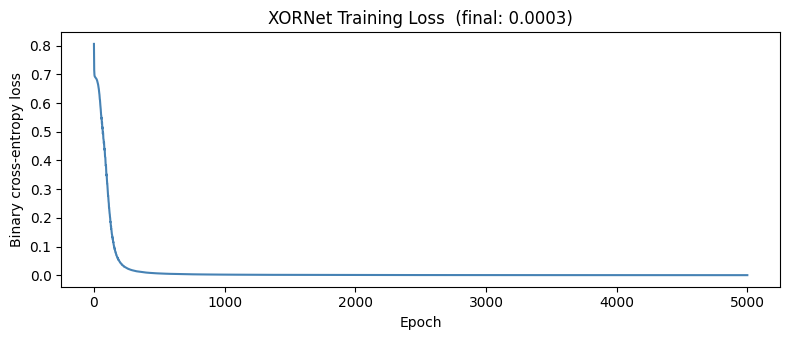

Final predictions:
  x=[0.0, 0.0]  true=0  p=0.000  pred=0  ✓
  x=[0.0, 1.0]  true=1  p=1.000  pred=1  ✓
  x=[1.0, 0.0]  true=1  p=1.000  pred=1  ✓
  x=[1.0, 1.0]  true=0  p=0.000  pred=0  ✓

Accuracy: 100%


In [5]:
# Train XORNet using the same five-step loop from notebook 19_0_3.
# The only additions: nn.BCELoss for the loss, and torch.optim.SGD so we
# do not have to loop over all 17 parameters manually each step.
# (Optimizers are covered in depth in notebook 19_1_2.)

torch.manual_seed(42)
model     = XORNet()
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

n_epochs = 5000
history  = []

for epoch in range(n_epochs):
    optimizer.zero_grad()             # (1) zero gradients
    pred = model(X_xor)               # (2) forward pass
    loss = criterion(pred, y_xor)     # (3) compute BCELoss
    loss.backward()                   # (4) backward pass
    optimizer.step()                  # (5) update all 17 parameters
    history.append(loss.item())

# Plot the loss curve
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(history, 'steelblue', lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary cross-entropy loss')
ax.set_title(f'XORNet Training Loss  (final: {history[-1]:.4f})')
plt.tight_layout()
plt.show()

# Final predictions
print('Final predictions:')
with torch.no_grad():
    for xi, yi, pi in zip(X_xor, y_xor, model(X_xor)):
        label = int(pi.item() > 0.5)
        match = '✓' if label == int(yi.item()) else '✗'
        print(f'  x={xi.tolist()}  true={int(yi.item())}  p={pi.item():.3f}  pred={label}  {match}')

with torch.no_grad():
    acc = (model(X_xor).round() == y_xor).float().mean().item()
print(f'\nAccuracy: {acc:.0%}')

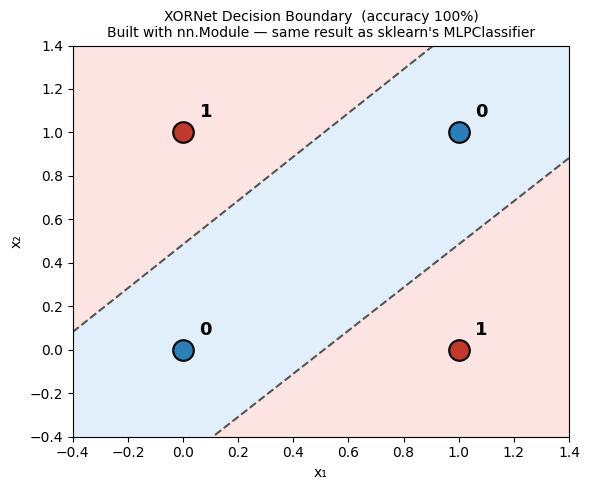

In [6]:
# Decision boundary — compare to the sklearn version in notebook 18_2_3
xx, yy = np.meshgrid(np.linspace(-0.4, 1.4, 250), np.linspace(-0.4, 1.4, 250))
grid   = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = model(grid).numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
cmap_bg = mcolors.ListedColormap(['#D6EAF8', '#FADBD8'])
ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap=cmap_bg, alpha=0.75)
ax.contour( xx, yy, Z, levels=[0.5], colors='#555', linewidths=1.5, linestyles='--')

for xi, yi in zip(X_xor.numpy(), y_xor.numpy()):
    color = '#C0392B' if yi[0] == 1 else '#2980B9'
    ax.scatter(*xi, c=color, s=220, zorder=5, edgecolors='black', lw=1.5)
    ax.text(xi[0]+0.06, xi[1]+0.07, str(int(yi[0])), fontsize=13, fontweight='bold')

ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title(f'XORNet Decision Boundary  (accuracy {acc:.0%})\n'
             f'Built with nn.Module — same result as sklearn\'s MLPClassifier',
             fontsize=10)
plt.tight_layout()
plt.show()

The network learned a non-linear decision boundary and correctly classified all four XOR points. This is the same result you saw in notebook 18_2_3 — where, notably, sklearn's `MLPClassifier` needed `activation='tanh', solver='lbfgs'` to solve XOR reliably, because the deep-learning defaults can get stuck on a 4-point dataset. The difference now: you built every piece yourself, so the knobs that matter (activation, optimizer, learning rate) are all visible in your own code.

---

## Section 4: `nn.Sequential` — Shorthand for Simple Stacks

When layers run in a straight line — input goes in, output comes out, no branching — you can skip the `__init__` / `forward` boilerplate and use `nn.Sequential` instead. It takes the layers as positional arguments and runs them in order.

The two styles produce identical networks. Choose based on complexity:
- **`nn.Sequential`** — when every forward pass is just "apply these layers in order"
- **`nn.Module` class** — when you need multiple inputs, skip connections, shared weights, or any logic beyond a straight pipeline

In [7]:
# The same XORNet written as nn.Sequential
# Note: use nn.ReLU() and nn.Sigmoid() (module versions), not torch.relu / torch.sigmoid
xor_seq = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

print('nn.Sequential automatically names each layer by index:')
print(xor_seq)
print()

# Introspecting any model — named_parameters() gives shape and name of every tensor
print('Named parameters and shapes:')
for name, param in xor_seq.named_parameters():
    print(f'  {name:<18}  shape: {list(param.shape)}  ({param.numel()} values)')
total = sum(p.numel() for p in xor_seq.parameters())
print(f'  Total: {total} trainable parameters')
print()

# state_dict() is a snapshot of all parameters by name — used for saving/loading models
print('state_dict() keys:')
for key, val in xor_seq.state_dict().items():
    print(f'  {key:<18}  {list(val.shape)}')

nn.Sequential automatically names each layer by index:
Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)

Named parameters and shapes:
  0.weight            shape: [4, 2]  (8 values)
  0.bias              shape: [4]  (4 values)
  2.weight            shape: [1, 4]  (4 values)
  2.bias              shape: [1]  (1 values)
  Total: 17 trainable parameters

state_dict() keys:
  0.weight            [4, 2]
  0.bias              [4]
  2.weight            [1, 4]
  2.bias              [1]


---

## Putting It All Together

| Concept | What it means |
|---|---|
| `nn.Module` | Base class for every PyTorch model; requires `__init__` (define layers) and `forward` (define computation) |
| `nn.Linear(in, out)` | A fully connected layer: stores weight of shape (out, in) and bias of shape (out,); forward computes `input @ weight.T + bias` |
| `model(x)` | Calls `model.forward(x)` automatically |
| `torch.relu` / `nn.ReLU()` | The hidden-layer activation: `max(0, z)`; allows the network to learn non-linear boundaries |
| `torch.sigmoid` / `nn.Sigmoid()` | The output activation for binary classification: maps any real number to (0, 1) |
| `nn.BCELoss()` | Binary cross-entropy: penalizes confident wrong predictions more than uncertain ones |
| `model.parameters()` | Iterator over all trainable tensors registered in the module hierarchy |
| `model.named_parameters()` | Same, but also yields the name of each tensor |
| `model.state_dict()` | Ordered dict of all named parameter tensors; used for saving and loading models |
| `nn.Sequential` | Shorthand for a straight-line stack of layers |

**Logistic regression → neural network:** Both use `nn.Linear`. Logistic regression has no hidden layer — it is a single linear transformation followed by sigmoid. Adding a hidden layer (Linear → ReLU → Linear → sigmoid) adds one learned transformation, giving the model the ability to form non-linear decision boundaries.

**What is coming next:** This notebook focused on the model. The next notebook, 19_1_2, focuses on the training machinery — data loaders, mini-batches, optimizers, and the validation loop. It applies the full pattern to the Wisconsin breast cancer dataset from the ensemble unit.